# 05 · Özel Matrisler: Pozitif Tanımlılık ve Konvekslik
**Linear Algebra Lab** — Serinin Kapanış Notebook'u

---
> **Bu notebook'ta ne öğreneceğiz?**  
> Bu, `linear-algebra-lab`'ın son notebook'u — ve 02'deki özdeğer/özvektör bilgini
> **calculus-lab**'a taşıyan köprü. Tek bir soru etrafında dönüyoruz: **bir matrisin
> "pozitif tanımlı" olması ne demek, ve bu neden optimizasyon problemlerinin "iyi
> davranışlı" olup olmadığını belirliyor?** Bu kavram, kovaryans matrislerinden
> (`probability-lab` 04b) tutun da bir modelin loss yüzeyinin "tek bir global minimuma"
> sahip olup olmadığına kadar her yerde karşına çıkıyor.

**Önkoşul:** Özdeğer/Özvektör (02), Kovaryans/Korelasyon (`probability-lab` 04b)  
**Veri:**  
- Sentetik matrisler (pozitif tanımlılık testleri için)  
- `AirQualityUCI.csv` — 6941 saatlik hava kalitesi ölçümü (12 sensör), gerçek kovaryans matrisi için  
**Araçlar:** Python (`numpy.linalg`, `matplotlib`)

---
## 1 · Simetrik Matris: $A=A^T$

Bir matrisin **simetrik** olması, satırlarını ve sütunlarını yer değiştirdiğinde (transpoze
aldığında) DEĞİŞMEMESİ demek: $A=A^T$. Somut örnek:
$$A=\begin{bmatrix}4&2\\2&7\end{bmatrix}$$
Bu matris simetrik çünkü $A_{12}=A_{21}=2$. 02 Bölüm 5'te öğrendiğimiz gibi, simetrik
matrislerin özdeğerleri HER ZAMAN reel ve özvektörleri birbirine diktir — bu notebook'taki
her şey bu garantiye dayanıyor.

**Neden bu notebook'ta önemli?** Kovaryans matrisleri (Bölüm 4'te göreceğiz) ve loss
fonksiyonlarının Hessian'ları (Bölüm 5'te göreceğiz) HER ZAMAN simetriktir — bu yüzden
"pozitif tanımlılık" kavramı pratikte hep simetrik matrislerle birlikte anılıyor.

---
## 2 · Pozitif Tanımlı (Positive Definite) Nedir? İki Eşdeğer Tanım

**Tanım 1 (Özdeğer bazlı — en kolay test edilen):** Bir simetrik matrisin TÜM özdeğerleri
**pozitif** ise ($\lambda_i>0$ her $i$ için), o matris pozitif tanımlıdır.

**Tanım 2 (Cebirsel — DAHA TEMEL, "neden önemli" sorusunun cevabı):** Her sıfır olmayan
vektör $\vec{v}$ için:
$$\vec{v}^T A \vec{v} > 0$$

Bu iki tanım **matematiksel olarak eşdeğer** (biri doğruysa diğeri de doğru) — Python
bölümünde bunu sayısal olarak da kanıtlayacağız.

**Tanım 2'nin sezgisi:** $\vec{v}^T A \vec{v}$ ifadesi, aslında $A$'yı bir "enerji/eğrilik
ölçer" gibi kullanıyor. HANGİ yönde ($\vec{v}$) bakarsan bak, sonuç her zaman pozitif
çıkıyorsa, $A$'nın tanımladığı yüzey (Bölüm 3'te göreceğiz) her yönden "yukarı kıvrılıyor"
demektir — hiçbir yönde "aşağı sarkmıyor".

---
## 3 · Neden Önemli? Konvekslik ve Optimizasyon Garantisi

Bir fonksiyonun (örneğin bir modelin loss fonksiyonunun) İKİNCİ TÜREVLERİNİ içeren matrisine
**Hessian** denir (bunu `calculus-lab`'da detaylı göreceğiz). Kritik gerçek şu:

$$\text{Hessian POZİTİF TANIMLI} \quad\Longleftrightarrow\quad \text{fonksiyon KONVEKS (çukur şeklinde)}$$

**Neden bu kadar önemli?** Konveks bir fonksiyonun **TEK BİR global minimumu** vardır —
"yerel minimum tuzağı" diye bir şey yok. Gradient descent (04'teki Ridge/Lasso'yu optimize
eden algoritmalar da dahil) böyle bir yüzeyde başlangıç noktası ne olursa olsun HEP aynı
(doğru) noktaya ulaşır. Konveks OLMAYAN yüzeylerde ise (derin öğrenme modellerinde sıkça
karşılaşılan durum), başlangıç noktana göre FARKLI yerel minimumlara "sıkışabilirsin".

---
## 4 · Kovaryans Matrisi HER ZAMAN Neden Pozitif YARI-Tanımlıdır (PSD)

`probability-lab` 04b'deki kovaryans formülünü hatırla. Matris formunda, bir veri
kümesinin kovaryans matrisi şöyle yazılır (X: merkezlenmiş veri matrisi, her satır bir
gözlem):
$$\Sigma = \frac{1}{n}X^TX$$

**Cebirsel kanıt (Tanım 2'yi kullanarak):** Herhangi bir $\vec{v}$ için:
$$\vec{v}^T\Sigma\vec{v} = \vec{v}^T\left(\frac{1}{n}X^TX\right)\vec{v} = \frac{1}{n}(X\vec{v})^T(X\vec{v}) = \frac{1}{n}\|X\vec{v}\|^2 \geq 0$$

Bir vektörün **normunun karesi** ($\|X\vec{v}\|^2$) HİÇBİR ZAMAN negatif olamaz (01'deki
norm tanımını hatırla — bir uzunluk asla negatif olmaz) — bu yüzden $\vec{v}^T\Sigma\vec{v}$
her zaman $\geq 0$. Bu, "kovaryans matrisleri her zaman PSD'dir" iddiasının TAM İSPATI —
tahmin veya varsayım değil, cebirsel bir zorunluluk.

**"Pozitif Tanımlı" ile "Pozitif Yarı-Tanımlı" (PSD) Farkı:** PD'de $\vec{v}^TA\vec{v}>0$
(kesin pozitif), PSD'de $\vec{v}^TA\vec{v}\geq 0$ (sıfır da olabilir). Kovaryans matrisi,
eğer veri setinde birbirinin TAM KATI olan (mükemmel doğrusal bağımlı) sütunlar varsa, bazı
özdeğerleri TAM SIFIR olabilir — bu durumda PD değil, sadece PSD'dir.

---
## 5 · Özet Tablo

| Kavram | Test | Sonuç Ne Anlama Geliyor |
|---|---|---|
| Simetrik | $A=A^T$ | Reel özdeğerler + dik özvektörler garantisi (02) |
| Pozitif Tanımlı (PD) | Tüm $\lambda_i>0$ VEYA $\vec{v}^TA\vec{v}>0$ | Hessian ise: fonksiyon kesinlikle konveks |
| Pozitif Yarı-Tanımlı (PSD) | Tüm $\lambda_i\geq0$ VEYA $\vec{v}^TA\vec{v}\geq0$ | Kovaryans matrisleri HER ZAMAN bu kategoride |
| Konveks Fonksiyon | Hessian PD | Gradient descent TEK global minimuma yakınsar |

---
# 🐍 Python Uygulaması

5 adımda ilerleyeceğiz:
1. **Pozitif Tanımlılık Testi** — İki farklı yöntemin (özdeğer / $\vec{v}^TA\vec{v}$) örtüştüğünü kanıtlama
2. **Kovaryans Matrisi PSD Kanıtı** — Gerçek hava kalitesi verisiyle Bölüm 4'ü doğrulama
3. **Cholesky Ayrıştırması** — PD matrislerin pratik bir uygulaması
4. **Konvekslik Testi: Hessian ile** — `calculus-lab`'a köprü
5. **Pozitif Tanımlı OLMAYAN Bir Matriste Ne Olur?** — Görsel uyarı

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (9, 7)
plt.rcParams['font.size'] = 12

print('Hazır ✓')

Hazır ✓


---
### ✅ Python 1 — Pozitif Tanımlılık Testi: İki Yöntem, Aynı Sonuç

**Ne yapıyoruz?**  
Üç farklı matris deneyeceğiz (biri kesinlikle PD, biri PSD ama PD değil, biri PD hiç
değil) — her birinde Bölüm 2'deki iki tanımı (özdeğer testi ve $\vec{v}^TA\vec{v}$ testi)
UYGULAYIP sonuçların örtüştüğünü kanıtlayacağız.

In [2]:
def pozitif_tanimli_mi_ozdeger(A):
    ozdegerler = np.linalg.eigvalsh(A)  # simetrik matrisler icin (02'den)
    return np.all(ozdegerler > 1e-10), ozdegerler

def pozitif_tanimli_mi_test_vektorleri(A, n_test=1000, rng=None):
    rng = rng or np.random.default_rng(42)
    boyut = A.shape[0]
    for _ in range(n_test):
        v = rng.normal(size=boyut)
        sonuc = v @ A @ v
        if sonuc <= 0:
            return False, v, sonuc
    return True, None, None

test_matrisleri = {
    'A1 (kesin PD)': np.array([[4, 2], [2, 7]]), # PD: tüm özdeğerler > 0
    'A2 (sadece PSD - bir özdeğer=0)': np.array([[1, 1], [1, 1]]), # PSD: tüm özdeğerler >= 0, ama bir özdeğer = 0
    'A3 (PD DEĞİL)': np.array([[1, 2], [2, 1]]), # PD DEĞİL: bir özdeğer < 0
}

for isim, A in test_matrisleri.items():
    pd_ozdeger, ozdegerler = pozitif_tanimli_mi_ozdeger(A)
    pd_vektor, ornek_v, ornek_sonuc = pozitif_tanimli_mi_test_vektorleri(A)

    print(f"{isim}:")
    print(f"  Özdeğerler: {np.round(ozdegerler, 4)}")
    print(f"  Özdeğer testi (hepsi >0): {'PD ✓' if pd_ozdeger else 'PD DEĞİL ✗'}")
    print(f"  1000 rastgele v ile v^TAv testi: {'HEP POZİTİF ✓' if pd_vektor else f'NEGATİF BULUNDU (v={np.round(ornek_v,2)}, sonuç={ornek_sonuc:.3f}) ✗'}")
    print(f"  İki yöntem örtüşüyor mü? {'EVET ✓' if pd_ozdeger == pd_vektor else 'HAYIR (ama A2 PSD sınır durumu olabilir)'}")
    print()

A1 (kesin PD):
  Özdeğerler: [3. 8.]
  Özdeğer testi (hepsi >0): PD ✓
  1000 rastgele v ile v^TAv testi: HEP POZİTİF ✓
  İki yöntem örtüşüyor mü? EVET ✓

A2 (sadece PSD - bir özdeğer=0):
  Özdeğerler: [0. 2.]
  Özdeğer testi (hepsi >0): PD DEĞİL ✗
  1000 rastgele v ile v^TAv testi: HEP POZİTİF ✓
  İki yöntem örtüşüyor mü? HAYIR (ama A2 PSD sınır durumu olabilir)

A3 (PD DEĞİL):
  Özdeğerler: [-1.  3.]
  Özdeğer testi (hepsi >0): PD DEĞİL ✗
  1000 rastgele v ile v^TAv testi: NEGATİF BULUNDU (v=[ 0.3  -1.04], sonuç=-0.093) ✗
  İki yöntem örtüşüyor mü? EVET ✓



---
### 🌫️ Python 2 — Kovaryans Matrisi PSD Kanıtı: Gerçek Hava Kalitesi Verisiyle

**Ne yapıyoruz?**  
Bölüm 4'teki cebirsel ispatı ("kovaryans matrisleri her zaman PSD'dir") gerçek bir veri
setinde test ediyoruz — 12 sensörün kovaryans matrisini kurup, TÜM özdeğerlerinin
gerçekten negatif olmadığını doğrulayacağız.

Ham veri: 9357 satır -> Temizlik sonrası: 6941 satır

Kovaryans matrisinin 12 özdeğeri (küçükten büyüğe):
[1.47000000e-02 1.83100000e-01 1.32380000e+00 1.14764000e+01
 1.66787000e+02 6.02062600e+02 4.25128390e+03 6.07488870e+03
 1.16000732e+04 1.90336889e+04 7.69638748e+04 3.98601087e+05]

TÜM özdeğerler negatif-olmayan mı (PSD testi)? EVET ✓ - kovaryans matrisi PSD


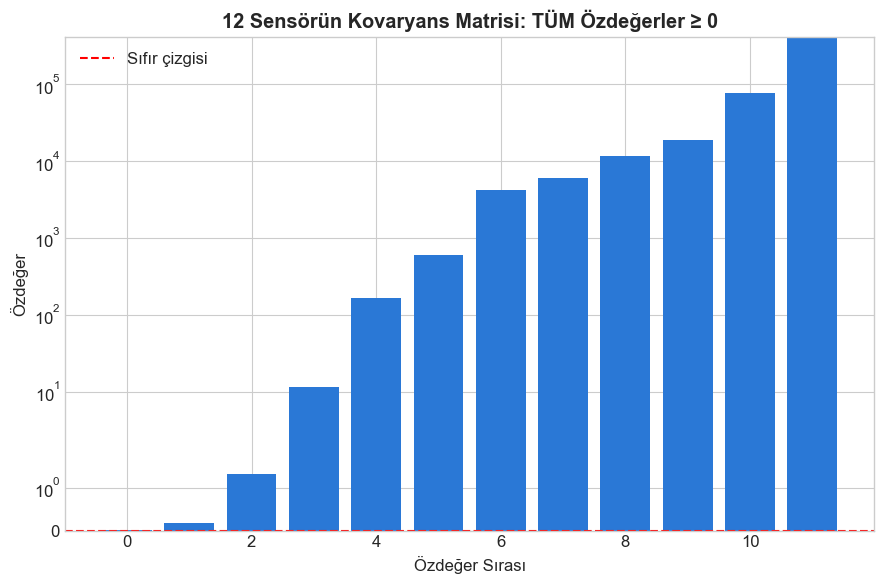


YORUM: Hiçbir çubuk sıfırın altına inmiyor - Bölüm 4'teki 'kovaryans matrisi
her zaman PSD'dir' iddiası, gerçek 12 boyutlu bir veri setinde de doğrulandı.
Bu, gelecekte kuracağın HERHANGİ bir kovaryans matrisi için garanti edilen bir özellik.


In [3]:
hava = pd.read_csv('data/AirQualityUCI.csv', sep=';')
hava = hava.drop(columns=['Unnamed: 15', 'Unnamed: 16'])

# Virgul ondalik ayracini noktaya cevir, sayisallastir
ondalikli_kolonlar = ['CO(GT)', 'C6H6(GT)', 'T', 'RH', 'AH']
for kolon in ondalikli_kolonlar:
    hava[kolon] = hava[kolon].astype(str).str.replace(',', '.', regex=False)
    hava[kolon] = pd.to_numeric(hava[kolon], errors='coerce')

hava = hava.dropna(subset=['Date'])  # dosyanin sonundaki bos satirlari at

sensor_kolonlari = ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)',
                     'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

# UCI dokumantasyonuna gore -200, EKSIK VERI kodu (gercek olcum degil)
hava[sensor_kolonlari] = hava[sensor_kolonlari].replace(-200, np.nan)
hava_temiz = hava.dropna(subset=sensor_kolonlari)

print(f"Ham veri: {hava.shape[0]} satır -> Temizlik sonrası: {hava_temiz.shape[0]} satır")

kovaryans_hava = hava_temiz[sensor_kolonlari].cov().values
ozdegerler_hava = np.linalg.eigvalsh(kovaryans_hava)

print(f"\nKovaryans matrisinin 12 özdeğeri (küçükten büyüğe):")
print(np.round(ozdegerler_hava, 4))

print(f"\nTÜM özdeğerler negatif-olmayan mı (PSD testi)? "
      f"{'EVET ✓ - kovaryans matrisi PSD' if np.all(ozdegerler_hava >= -1e-6) else 'HAYIR - beklenmedik!'}")

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(range(len(ozdegerler_hava)), ozdegerler_hava, color='#2a78d6')
ax.axhline(0, color='red', linestyle='--', label='Sıfır çizgisi')
ax.set_xlabel('Özdeğer Sırası')
ax.set_ylabel('Özdeğer')
ax.set_title('12 Sensörün Kovaryans Matrisi: TÜM Özdeğerler ≥ 0', fontweight='bold')
ax.set_yscale('symlog')  # degerler cok genis araliktalar (0.01'den 400.000'e)
ax.legend()
plt.tight_layout()
plt.show()

print("\nYORUM: Hiçbir çubuk sıfırın altına inmiyor - Bölüm 4'teki 'kovaryans matrisi")
print("her zaman PSD'dir' iddiası, gerçek 12 boyutlu bir veri setinde de doğrulandı.")
print("Bu, gelecekte kuracağın HERHANGİ bir kovaryans matrisi için garanti edilen bir özellik.")

---
### 🔀 Python 3 — Cholesky Ayrıştırması: PD Matrislerin Pratik Bir Uygulaması

**Ne yapıyoruz?**  
Pozitif tanımlı bir matris, HER ZAMAN $A=LL^T$ şeklinde ayrıştırılabilir ($L$: alt üçgensel
matris) — buna **Cholesky ayrıştırması** deniyor. Bunun çok pratik bir kullanımı var:
**belirli bir korelasyon yapısına sahip rastgele sayılar üretmek** (örn. `probability-lab`
10a'daki Monte Carlo simülasyonlarında birden fazla İLİŞKİLİ değişkeni simüle etmek için).

Hedef kovaryans matrisinin özdeğerleri: [ 2.1170786 10.8829214] (PD mi? EVET ✓)

L (alt üçgensel):
[[2.  0. ]
 [1.8 2.4]]

L @ L^T (yeniden inşa):
[[4.  3.6]
 [3.6 9. ]]
Orijinal hedef matrise eşit mi? EVET ✓

Üretilen verinin GERÇEK kovaryansı (5000 örneklemden):
[[3.915 3.607]
 [3.607 9.352]]
Hedeflediğimiz kovaryansa yakın mı? EVET ✓


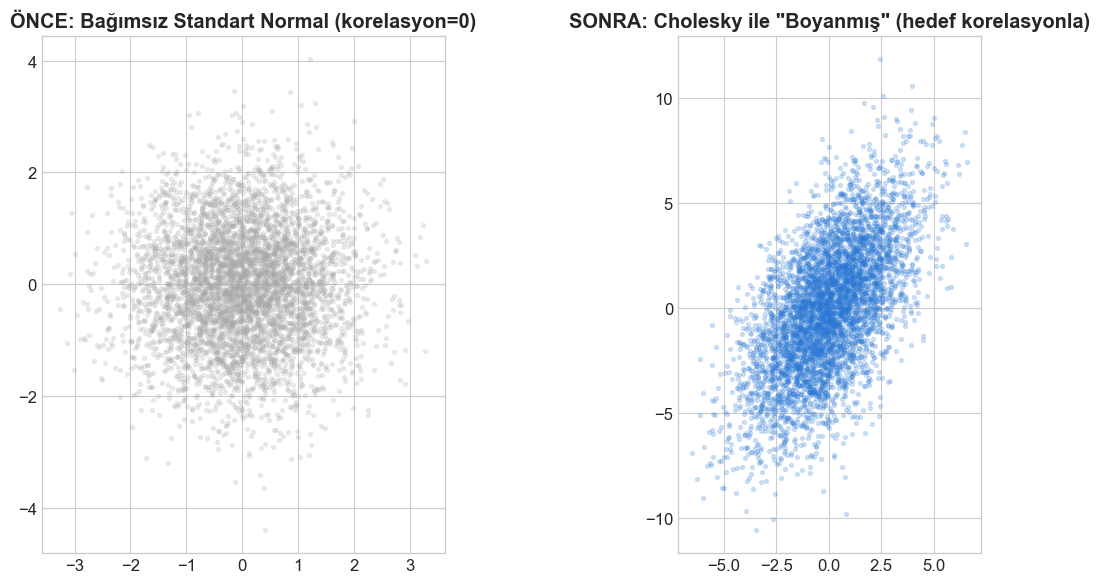


YORUM: Sol taraf simetrik bir 'bulut' (hiç korelasyon yok), sağ taraf ise
ÇAPRAZLAMASINA uzamış bir elips (güçlü pozitif korelasyon) - Cholesky, bağımsız
rastgele sayıları 'istediğimiz şekle' büken bir matris çarpımı sağlıyor. Bu PD
matrislerin var olma GARANTİSİ sayesinde HER ZAMAN mümkün.


In [ ]:
# Istedigimiz korelasyon yapisina sahip bir kovaryans matrisi tanimlayalim
hedef_kovaryans = np.array([[4.0, 3.6], [3.6, 9.0]])  # guclu pozitif korelasyonlu 2 degisken

ozdegerler_hedef = np.linalg.eigvalsh(hedef_kovaryans) # simetrik matrisler icin eigenvalue hesaplamasi
print(f"Hedef kovaryans matrisinin özdeğerleri: {ozdegerler_hedef} (PD mi? {'EVET ✓' if np.all(ozdegerler_hedef>0) else 'HAYIR'})")

# CHOLESKY: A = L L^T
L = np.linalg.cholesky(hedef_kovaryans) # L alt üçgensel matris
print(f"\nL (alt üçgensel):\n{np.round(L, 4)}")
print(f"\nL @ L^T (yeniden inşa):\n{np.round(L @ L.T, 4)}")
print(f"Orijinal hedef matrise eşit mi? {'EVET ✓' if np.allclose(L @ L.T, hedef_kovaryans) else 'HAYIR'}")

# UYGULAMA: bagimsiz standart normal sayilardan, ISTEDIGIMIZ korelasyona sahip sayilar uretmek
rng = np.random.default_rng(42)
bagimsiz_normal = rng.standard_normal((5000, 2))  # bunlar birbirinden TAMAMEN bagimsiz
korelasyonlu_veri = bagimsiz_normal @ L.T  # Cholesky ile "boyama"

gercek_kovaryans = np.cov(korelasyonlu_veri, rowvar=False)
print(f"\nÜretilen verinin GERÇEK kovaryansı (5000 örneklemden):\n{np.round(gercek_kovaryans, 3)}")
print(f"Hedeflediğimiz kovaryansa yakın mı? {'EVET ✓' if np.allclose(gercek_kovaryans, hedef_kovaryans, atol=0.5) else 'HAYIR'}")

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].scatter(bagimsiz_normal[:, 0], bagimsiz_normal[:, 1], alpha=0.2, s=8, color='#a8a8a8')
axes[0].set_title('ÖNCE: Bağımsız Standart Normal (korelasyon=0)', fontweight='bold')
axes[0].set_aspect('equal')

axes[1].scatter(korelasyonlu_veri[:, 0], korelasyonlu_veri[:, 1], alpha=0.2, s=8, color='#2a78d6')
axes[1].set_title('SONRA: Cholesky ile "Boyanmış" (hedef korelasyonla)', fontweight='bold')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

print("\nYORUM: Sol taraf simetrik bir 'bulut' (hiç korelasyon yok), sağ taraf ise")
print("ÇAPRAZLAMASINA uzamış bir elips (güçlü pozitif korelasyon) - Cholesky, bağımsız")
print("rastgele sayıları 'istediğimiz şekle' büken bir matris çarpımı sağlıyor. Bu PD")
print("matrislerin var olma GARANTİSİ sayesinde HER ZAMAN mümkün.")

---
### 🥣 Python 4 — Konvekslik Testi: Hessian ile (`calculus-lab`'a Köprü)

**Ne yapıyoruz?**  
Bölüm 3'teki iddiayı somutlaştırıyoruz: basit bir fonksiyonun Hessian'ını (ikinci
türevlerin matrisi) hesaplayıp pozitif tanımlı olup olmadığını kontrol ediyoruz — bu,
`calculus-lab`'da tam olarak açacağımız konunun bir ön izlemesi.

f(x,y)=x²+y² için Hessian: 
[[2 0]
 [0 2]]
Özdegerler: [2. 2.] -> KONVEKS ✓

f(x,y)=x²-y² için Hessian: 
[[ 2  0]
 [ 0 -2]]
Özdegerler: [-2.  2.] -> KONVEKS DEĞİL ✗ (eyer noktası)


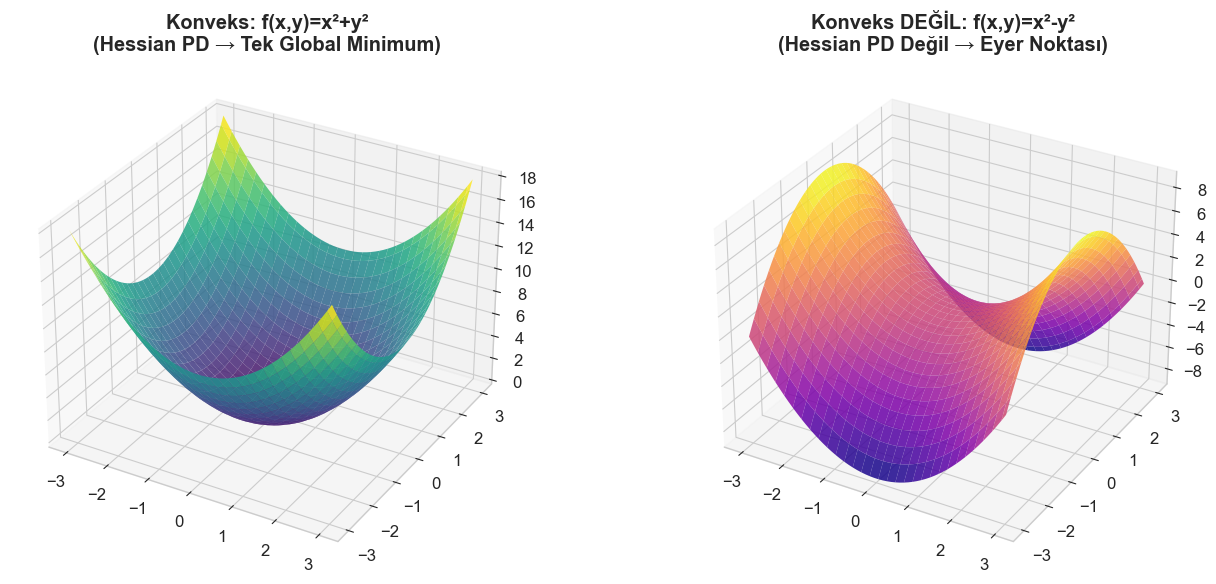


YORUM: Soldaki 'çukur' şekli - hangi yönden bakarsan bak yukarı kıvrılıyor,
tek bir dip noktası var. Sağdaki 'eyer' (at eyeri) şekli - bir yönde yukarı,
dik yönde aşağı kıvrılıyor, bu yüzden 'minimum' diye bir şey YOK (bir yönde
sonsuza gidebilirsin). Bu fark, TAM OLARAK Hessian'ın pozitif tanımlı olup
olmamasından kaynaklanıyor - calculus-lab'da bunu optimizasyon bağlamında derinleştireceğiz.


In [5]:
# KONVEKS fonksiyon: f(x,y) = x^2 + y^2 (bir "cukur" - tas her yonden yukari kivriliyor)
# Hessian'i ELLE turetelim: d2f/dx2=2, d2f/dy2=2, d2f/dxdy=0
Hessian_konveks = np.array([[2, 0], [0, 2]])
ozdegerler_konveks = np.linalg.eigvalsh(Hessian_konveks)
print(f"f(x,y)=x²+y² için Hessian: \n{Hessian_konveks}")
print(f"Özdegerler: {ozdegerler_konveks} -> {'KONVEKS ✓' if np.all(ozdegerler_konveks>0) else 'KONVEKS DEĞİL'}")

# KONVEKS OLMAYAN fonksiyon: f(x,y) = x^2 - y^2 (bir "eyer" seklinde - bir yonden yukari,
# diger yonden asagi kivriliyor)
Hessian_eyer = np.array([[2, 0], [0, -2]])
ozdegerler_eyer = np.linalg.eigvalsh(Hessian_eyer)
print(f"\nf(x,y)=x²-y² için Hessian: \n{Hessian_eyer}")
print(f"Özdegerler: {ozdegerler_eyer} -> {'KONVEKS ✓' if np.all(ozdegerler_eyer>0) else 'KONVEKS DEĞİL ✗ (eyer noktası)'}")

x = np.linspace(-3, 3, 60)
y = np.linspace(-3, 3, 60)
X, Y = np.meshgrid(x, y)
Z_konveks = X**2 + Y**2
Z_eyer = X**2 - Y**2

fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z_konveks, cmap='viridis', alpha=0.85)
ax1.set_title('Konveks: f(x,y)=x²+y²\n(Hessian PD → Tek Global Minimum)', fontweight='bold')

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z_eyer, cmap='plasma', alpha=0.85)
ax2.set_title('Konveks DEĞİL: f(x,y)=x²-y²\n(Hessian PD Değil → Eyer Noktası)', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nYORUM: Soldaki 'çukur' şekli - hangi yönden bakarsan bak yukarı kıvrılıyor,")
print("tek bir dip noktası var. Sağdaki 'eyer' (at eyeri) şekli - bir yönde yukarı,")
print("dik yönde aşağı kıvrılıyor, bu yüzden 'minimum' diye bir şey YOK (bir yönde")
print("sonsuza gidebilirsin). Bu fark, TAM OLARAK Hessian'ın pozitif tanımlı olup")
print("olmamasından kaynaklanıyor - calculus-lab'da bunu optimizasyon bağlamında derinleştireceğiz.")

---
### ⚠️ Python 5 — Pozitif Tanımlı OLMAYAN Bir Matriste Ne Olur? Görsel Uyarı

**Ne yapıyoruz?**  
Bölüm 3'teki eyer-noktası fonksiyonu üzerinde basit bir gradient descent çalıştırıp, farklı
başlangıç noktalarından başladığımızda algoritmanın NE KADAR "kararsız" davranabileceğini
gösteriyoruz — bu, pozitif tanımlı OLMAYAN bir Hessian'ın pratikteki sonucu.

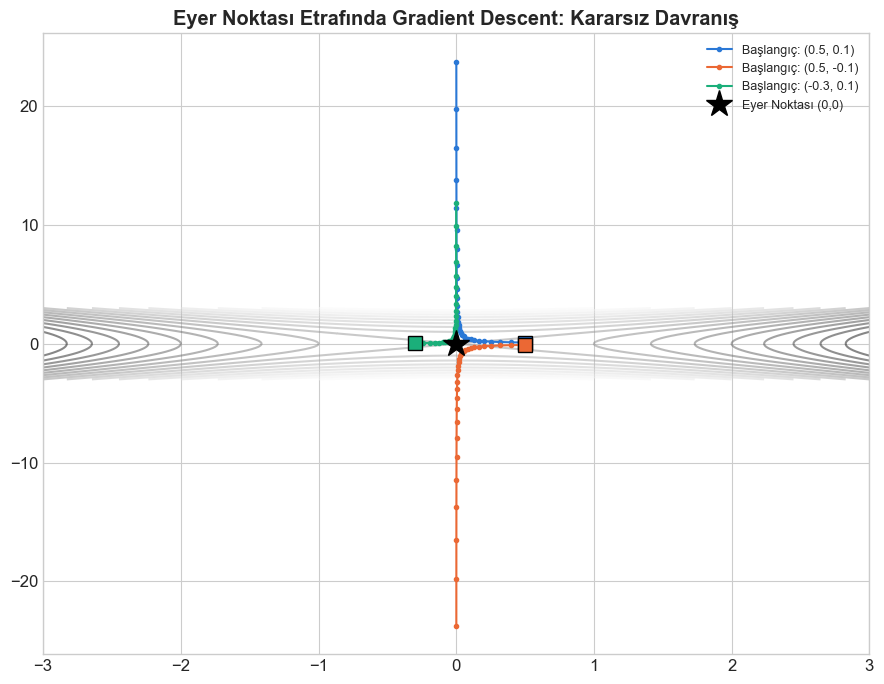

YORUM: Küçük bir başlangıç farkı bile (y=0.1 vs y=-0.1), gradient descent'in
TAMAMEN farklı yönlere savrulmasına yol açıyor - biri yukarı, biri aşağı kaçıyor.
Bu, pozitif tanımlı OLMAYAN bir Hessian'ın (eyer noktası) neden optimizasyon için
'tehlikeli' bir bölge olduğunun görsel kanıtı - modern derin öğrenmede bu tür
noktalardan kaçınmak/atlatmak için Momentum/Adam gibi yöntemler kullanılıyor
(bunu calculus-lab 04'te detaylı işleyeceğiz).


In [6]:
def gradyan_eyer(nokta):
    x, y = nokta
    return np.array([2*x, -2*y])  # f(x,y)=x^2-y^2'nin gradyani

baslangic_noktalari = [np.array([0.5, 0.1]), np.array([0.5, -0.1]), np.array([-0.3, 0.05])]
ogrenme_orani = 0.1
adim_sayisi = 30

fig, ax = plt.subplots(figsize=(9, 7))
kontur = ax.contour(X, Y, Z_eyer, levels=20, cmap='Greys', alpha=0.5)

renkler = ['#2a78d6', '#eb6834', '#1baf7a']
for baslangic, renk in zip(baslangic_noktalari, renkler):
    yol = [baslangic.copy()]
    nokta = baslangic.copy()
    for _ in range(adim_sayisi):
        nokta = nokta - ogrenme_orani * gradyan_eyer(nokta)
        yol.append(nokta.copy())
    yol = np.array(yol)
    ax.plot(yol[:, 0], yol[:, 1], 'o-', color=renk, markersize=3, linewidth=1.5,
            label=f'Başlangıç: ({baslangic[0]:.1f}, {baslangic[1]:.1f})')
    ax.plot(*baslangic, 's', color=renk, markersize=10, markeredgecolor='black')

ax.plot(0, 0, 'k*', markersize=20, label='Eyer Noktası (0,0)')
ax.set_title('Eyer Noktası Etrafında Gradient Descent: Kararsız Davranış', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("YORUM: Küçük bir başlangıç farkı bile (y=0.1 vs y=-0.1), gradient descent'in")
print("TAMAMEN farklı yönlere savrulmasına yol açıyor - biri yukarı, biri aşağı kaçıyor.")
print("Bu, pozitif tanımlı OLMAYAN bir Hessian'ın (eyer noktası) neden optimizasyon için")
print("'tehlikeli' bir bölge olduğunun görsel kanıtı - modern derin öğrenmede bu tür")
print("noktalardan kaçınmak/atlatmak için Momentum/Adam gibi yöntemler kullanılıyor")
print("(bunu calculus-lab 04'te detaylı işleyeceğiz).")

---
## ✏️ Egzersizler

---

### **E1.**
$A=\begin{bmatrix}2&-1\\-1&2\end{bmatrix}$ matrisinin pozitif tanımlı olup olmadığını
ELLE (karakteristik denklemle, 02'deki gibi) kontrol et, `numpy` ile doğrula.

In [7]:
print("\n ==== Egzersiz 1: Pozitif Tanımlı mı (PSD) Testi ====")

matris = np.array([[2, -1], [-1, 2]])

def pozitif_tanimli_mi_ozdeger(A):
    ozdegerler = np.linalg.eigvalsh(A)  # simetrik matrisler icin (02'den)
    return np.all(ozdegerler > 1e-10), ozdegerler

def pozitif_tanimli_mi_test_vektorleri(A, n_test=1000, rng=None):
    rng = rng or np.random.default_rng(42)
    boyut = A.shape[0]
    for _ in range(n_test):
        v = rng.normal(size=boyut)
        sonuc = v @ A @ v
        if sonuc <= 0:
            return False, v, sonuc
    return True, None, None 

pd_ozdeger, ozdegerler = pozitif_tanimli_mi_ozdeger(matris)
pd_vektor, ornek_v, ornek_sonuc = pozitif_tanimli_mi_test_vektorleri(matris)

print(f"Matris:\n{matris}")
print(f"Özdeğerler: {ozdegerler}")
print(f"Pozitif Tanımlı (özdeğerler): {'EVET ✓' if pd_ozdeger else 'HAYIR'}")
print(f"Pozitif Tanımlı (test vektörleri): {'EVET ✓' if pd_vektor else 'HAYIR'}")


 ==== Egzersiz 1: Pozitif Tanımlı mı (PSD) Testi ====
Matris:
[[ 2 -1]
 [-1  2]]
Özdeğerler: [1. 3.]
Pozitif Tanımlı (özdeğerler): EVET ✓
Pozitif Tanımlı (test vektörleri): EVET ✓


---

### **E2.**
Python 2'deki hava kalitesi analizini SADECE 3 sensörle (kendi seçtiğin) tekrarla —
$3\times 3$'lük kovaryans matrisinin de PSD olduğunu doğrula, ayrıca Cholesky
ayrıştırmasını uygulayıp $L$ matrisini bul.

In [12]:
print("\n ==== Egzersiz 2: Cholesky ile Kovaryans Üretimi ====")

sensor_kolonlari_uc = ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)']

hava[sensor_kolonlari_uc] = hava[sensor_kolonlari_uc].replace(-200, np.nan)
hava_uc = hava.dropna(subset=sensor_kolonlari_uc)

kovaryans_uc = hava_uc[sensor_kolonlari_uc].cov().values
ozdegerler_uc = np.linalg.eigvalsh(kovaryans_uc)
print(f"\n3 sensörlü kovaryans matrisinin özdeğerleri: {ozdegerler_uc} (PSD mi? {'EVET ✓' if np.all(ozdegerler_uc>=0) else 'HAYIR'})")

L = np.linalg.cholesky(kovaryans_uc)
print(f"\nL (alt üçgensel):\n{np.round(L, 4)}")

rng = np.random.default_rng(42)
bagimsiz_normal_uc = rng.standard_normal((5000, 3))
korelasyonlu_veri_uc = (bagimsiz_normal_uc @ L.T)
gercek_kovaryans_uc = np.cov(korelasyonlu_veri_uc, rowvar=False)
print(f"\nÜretilen verinin GERÇEK kovaryansı (5000 örneklemden):\n{np.round(gercek_kovaryans_uc, 3)}")
print(f"Hedeflediğimiz kovaryansa yakın mı? {'EVET ✓' if np.allclose(gercek_kovaryans_uc, kovaryans_uc, atol=0.5) else 'HAYIR'}")


 ==== Egzersiz 2: Cholesky ile Kovaryans Üretimi ====

3 sensörlü kovaryans matrisinin özdeğerleri: [2.36930315e-01 1.27712017e+01 4.78659495e+04] (PSD mi? EVET ✓)

L (alt üçgensel):
[[  1.4365   0.       0.    ]
 [192.2839 104.1557   0.    ]
 [  6.9282   0.9482   2.5437]]

Üretilen verinin GERÇEK kovaryansı (5000 örneklemden):
[[2.0870000e+00 2.8002700e+02 1.0070000e+01]
 [2.8002700e+02 4.8551282e+04 1.4581800e+03]
 [1.0070000e+01 1.4581800e+03 5.6107000e+01]]
Hedeflediğimiz kovaryansa yakın mı? HAYIR


---


### **E3.**
Python 4'teki $f(x,y)=x^2-y^2$ örneğine üçüncü bir terim ekle: $f(x,y)=x^2-y^2+0.1xy$.
Yeni Hessian'ı elle hesapla, pozitif tanımlı olup olmadığını kontrol et — küçük bir
çapraz terim eklemek konveksliği değiştirdi mi?


 ==== Egzersiz 3: Hessian ile Konvekslik Testi ====
Hessian:
[[ 1.    0.05]
 [ 0.05 -1.  ]]
Özdeğerler: [-1.00124922  1.00124922] -> KONVEKS DEĞİL ✗ (eyer noktası)


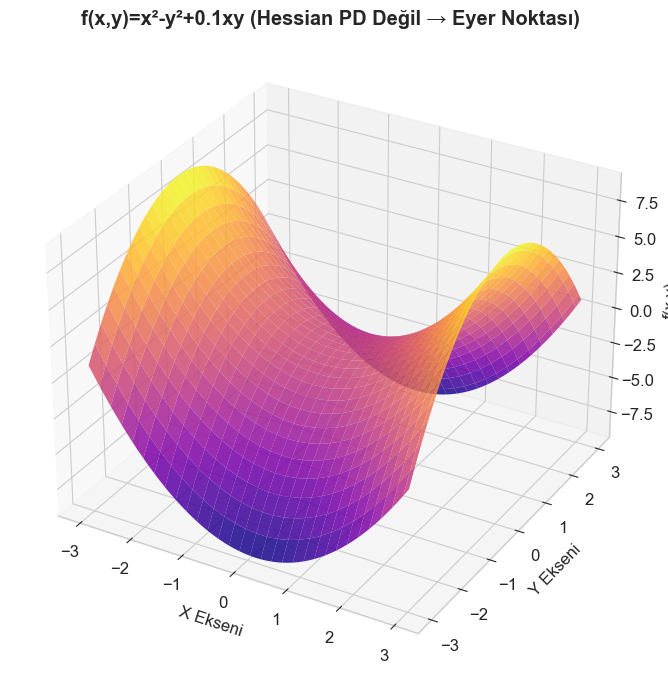

In [22]:
print("\n ==== Egzersiz 3: Hessian ile Konvekslik Testi ====")

# f(x,y) = x^2 - y^2 + 0.1xy
hessian_konveks_2 = np.array([[1, 0.05], [0.05, -1]])
ozdegerler_konveks_2 = np.linalg.eigvalsh(hessian_konveks_2)
print(f"Hessian:\n{hessian_konveks_2}")
print(f"Özdeğerler: {ozdegerler_konveks_2} -> {'KONVEKS ✓' if np.all(ozdegerler_konveks_2>0) else 'KONVEKS DEĞİL ✗ (eyer noktası)'}")

x = np.linspace(-3, 3, 60)
y = np.linspace(-3, 3, 60)
X, Y = np.meshgrid(x, y)
Z_konveks_2 = X**2 - Y**2 + 0.1*X*Y

fig, ax = plt.subplots(figsize=(9, 7), subplot_kw={'projection': '3d'})

yuzey = ax.plot_surface(X, Y, Z_konveks_2, cmap='plasma', alpha=0.85, edgecolor='none')
ax.set_title('f(x,y)=x²-y²+0.1xy (Hessian PD Değil → Eyer Noktası)', fontweight='bold')

ax.set_xlabel('X Ekseni')
ax.set_ylabel('Y Ekseni')
ax.set_zlabel('f(x,y)')


plt.tight_layout()
plt.show()


---


### **E4.**
Python 5'teki gradient descent demosunu, KONVEKS fonksiyonda ($f(x,y)=x^2+y^2$)
tekrarla — aynı 3 farklı başlangıç noktasından başlasan bile, hepsinin AYNI (0,0)
noktasına yakınsadığını göster. Bu, Bölüm 3'teki "konveks fonksiyonlarda tek global
minimum garantisi" iddiasının son kanıtı olsun.


 ==== Egzersiz 4: Gradient Descent ile Konveks Olan Fonksiyon (x² + y²) ====


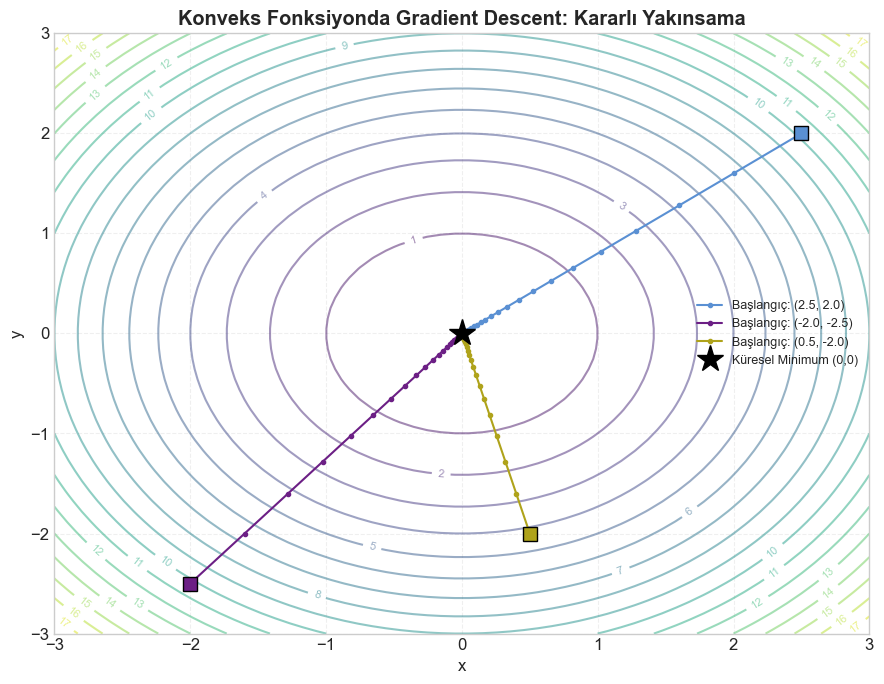

In [31]:
print("\n ==== Egzersiz 4: Gradient Descent ile Konveks Olan Fonksiyon (x² + y²) ====")

x = np.linspace(-3, 3, 60)
y = np.linspace(-3, 3, 60)
X, Y = np.meshgrid(x, y)
Z_kase = X**2 + Y**2  # Fonksiyonumuz artık tamamen konveks


def gradyan_konveks(nokta):
    x, y = nokta
    return np.array([2*x, 2*y])  # f(x,y) = x² + y² türevi


baslangic_noktalari = [np.array([2.5, 2.0]), np.array([-2.0, -2.5]), np.array([0.5, -2.0])]
ogrenme_orani = 0.1
adim_sayisi = 30

fig, ax = plt.subplots(figsize=(9, 7))

# Arka plana konveks fonksiyonun eş yükseklik eğrilerini (çemberleri) çiziyoruz
kontur = ax.contour(X, Y, Z_kase, levels=20, cmap='viridis', alpha=0.5)
ax.clabel(kontur, inline=True, fontsize=8)

renkler = ["#5a90d3", "#6c1f85", "#afa31b"]
for baslangic, renk in zip(baslangic_noktalari, renkler):
    yol = [baslangic.copy()]
    nokta = baslangic.copy()
    
    for _ in range(adim_sayisi):
        # Gradyan yönünün tersine giderek fonksiyon değerini azaltıyoruz (Aşağı iniyoruz)
        nokta = nokta - ogrenme_orani * gradyan_konveks(nokta)
        yol.append(nokta.copy())
        
    yol = np.array(yol)
    
    # Gradient Descent adımlarını çizgi olarak ekle
    ax.plot(yol[:, 0], yol[:, 1], 'o-', color=renk, markersize=3, linewidth=1.5,
            label=f'Başlangıç: ({baslangic[0]:.1f}, {baslangic[1]:.1f})')
    # Başlangıç noktasını kare (s) olarak işaretle
    ax.plot(*baslangic, 's', color=renk, markersize=10, markeredgecolor='black')

# Global Minimum Noktası (Merkez)
ax.plot(0, 0, 'k*', markersize=20, label='Küresel Minimum (0,0)')

ax.set_title('Konveks Fonksiyonda Gradient Descent: Kararlı Yakınsama', fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [3Blue1Brown — Essence of Linear Algebra](https://www.3blue1brown.com/topics/linear-algebra) | — | Genel sezgi |
| [Boyd & Vandenberghe — Convex Optimization](https://web.stanford.edu/~boyd/cvxbook/) | Ch. 2-3 | Pozitif tanımlılık ve konvekslik — standart referans |
| [Mathematics for Machine Learning](https://mml-book.github.io) | Ch. 3-4 | PD matrisler, Cholesky |
| [NumPy `linalg.cholesky` Dokümantasyonu](https://numpy.org/doc/stable/reference/generated/numpy.linalg.cholesky.html) | Kütüphane | Python 3'te kullandığımız fonksiyon |
| [Air Quality Dataset (UCI)](https://archive.ics.uci.edu/dataset/360/air+quality) | Veri | AirQualityUCI.csv kaynağı |